# HOTAIR Structure Probing Analysis

## Date:
Start: October 10, 2025

Last Updated: May 15, 2026

## Purpose:
For *Perry et al. 2026*.

Analysis of SHAPE-MaP chemical probing data of HOTAIR *in cellulo* and *in vitro*. Includes quality control metrics and identification of structurally significant regions using chemical reactivity and Shannon entropy metrics.

This code is provided as-is for reproducibility purposes and may be reused freely under the MIT License. No guarantees are made regarding functionality in other environments or use cases.

## Protocol:

### Import packages

In [2]:
# Used pip to install into environment if not already installed

In [11]:
# General and plotting
import pandas as pd
import openpyxl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from collections import Counter
# For QC
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
from itertools import combinations
from scipy.stats import ttest_ind
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import AutoMinorLocator

### Read all data from Excel

In [4]:
# Path to data file
file_path = "Data_input/Supplemental_Data_2_HOTAIR_SHAPE-MaP.xlsx"

# Read all sheets into a dictionary of DataFrames
data_dict = pd.read_excel(file_path, sheet_name=None)

# Check sheet names
print(data_dict.keys())

dict_keys(['18S_in_cellulo_rep1', '18S_in_cellulo_rep2', 'HOTAIR_in_cellulo_rep1', 'HOTAIR_in_cellulo_rep2', 'HOTAIR_in_cellulo_avg', 'HOTAIR_in_vitro_rep1', 'HOTAIR_in_vitro_rep2', 'HOTAIR_in_vitro_avg'])


In [5]:
# Check one sheet
df = data_dict['18S_in_cellulo_rep1']
df.head()

,Nucleotide,Sequence,Modified_rate,Untreated_rate,Norm_profile,Norm_stderr
0,1,u,NaN,0.0,NaN,NaN
1,2,a,NaN,0.0,NaN,NaN
2,3,c,NaN,0.0,NaN,NaN
3,4,c,NaN,0.0,NaN,NaN
4,5,u,NaN,0.0,NaN,NaN


In [7]:
# Check one sheet
df = data_dict['HOTAIR_in_cellulo_avg']
df.head()

,Nucleotide,Sequence,Norm_profile,Base_pair,Shannon
0,1,g,NaN,0,0.006313
1,2,a,NaN,0,0.008690
2,3,c,NaN,428,0.523165
3,4,u,NaN,427,0.632966
4,5,c,NaN,426,0.640268


### Pearson Correlations

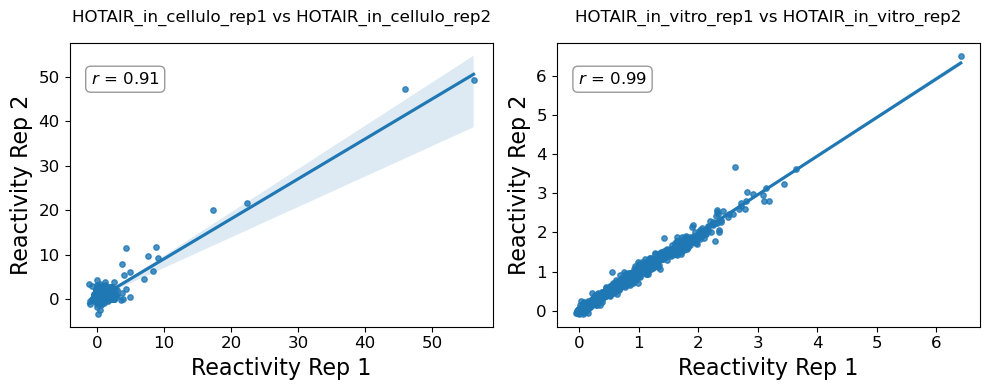

In [9]:
# Calculate correlations and plot scatterplot of reactivities

# Define pairs to compare:
pairs_to_plot = [
    ('HOTAIR_in_cellulo_rep1', 'HOTAIR_in_cellulo_rep2'),
    ('HOTAIR_in_vitro_rep1', 'HOTAIR_in_vitro_rep2')
]

results = []

# Compute correlations
for s1, s2 in pairs_to_plot:
    x = data_dict[s1]['Norm_profile']
    y = data_dict[s2]['Norm_profile']
    mask = x.notna() & y.notna()
    if len(x[mask]) > 1 and np.std(x[mask]) > 0 and np.std(y[mask]) > 0:
        r, p = pearsonr(x[mask], y[mask])
    else:
        r, p = np.nan, np.nan  # skip this pair
    results.append({'sample_i': s1,'sample_j': s2,'x': x[mask],'y': y[mask],'r': r,'p': p})

# Plot
cols = 2
rows = 1

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for ax, result in zip(axes, results):
    sns.regplot(x=result['x'], y=result['y'], ax=ax, scatter_kws={'s': 15})
    ax.set_title(f"{result['sample_i']} vs {result['sample_j']}",fontsize='12',pad=15)
    ax.set_xlabel('Reactivity Rep 1', fontsize='16')
    ax.set_ylabel('Reactivity Rep 2', fontsize='16')
    ax.text(0.05, 0.9, f"$r$ = {result['r']:.2f}",
            transform=ax.transAxes, fontsize=12, va='top',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    ax.tick_params(axis='both', labelsize=12, colors='black')

plt.tight_layout()
# plt.savefig(INSERT/PATH/TO/SAVE/"HOTAIR_Global_Pearson_Reactivities.png", dpi=300)
plt.show()


18S_in_cellulo_rep1_vs_18S_in_cellulo_rep2
  Pearson r = 0.988, p = 0.000e+00
  Spearman ρ = 0.739, p = 8.345e-213



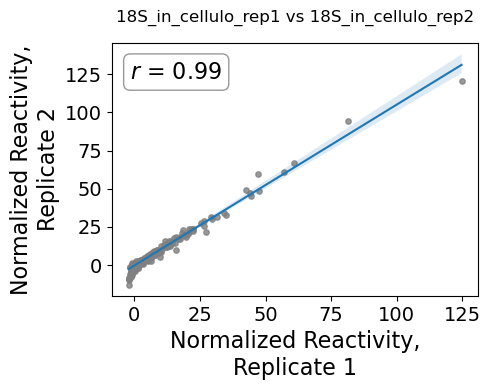

In [10]:
pairs_to_plot = [('18S_in_cellulo_rep1', '18S_in_cellulo_rep2')]

results = []

# Compute correlations
for s1, s2 in pairs_to_plot:
    x = data_dict[s1]['Norm_profile']
    y = data_dict[s2]['Norm_profile']
    mask = x.notna() & y.notna()
    if len(x[mask]) > 1 and np.std(x[mask]) > 0 and np.std(y[mask]) > 0:
        pearson_r, pearson_p = pearsonr(x[mask], y[mask])
        spearman_r, spearman_p = spearmanr(x[mask], y[mask])
    else:
        pearson_r = pearson_p = spearman_r = spearman_p = np.nan  # skip this pair
    results.append({'sample_i': s1,'sample_j': s2,'x': x[mask],'y': y[mask],'pearson_r': pearson_r,'pearson_p': pearson_p,'spearman_r': spearman_r,'spearman_p': spearman_p})
    print(f"{s1}_vs_{s2}")
    print(f"  Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
    print(f"  Spearman ρ = {spearman_r:.3f}, p = {spearman_p:.3e}\n")

# Plot
for result in results:
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.regplot(x=result['x'], y=result['y'], ax=ax, scatter_kws={'s': 15,'color': 'gray'}, line_kws={'color': '#1f77b4', 'linewidth': 1.5})
    ax.set_title(f"{result['sample_i']} vs {result['sample_j']}",fontsize='12', pad=15)
    ax.set_xlabel('Normalized Reactivity,\nReplicate 1', fontsize='16')
    ax.set_ylabel('Normalized Reactivity,\nReplicate 2', fontsize='16')
    ax.text(0.05, 0.93, f"$r$ = {result['pearson_r']:.2f}",
            transform=ax.transAxes, fontsize=16, va='top',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    # ax.text(0.1, 0.78, f"$ρ$ = {result['spearman_r']:.2f}",
    #         transform=ax.transAxes, fontsize=14, va='top',
    #         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    ax.tick_params(axis='both', labelsize=14, colors='black')
    ax.xaxis.set_major_locator(MultipleLocator(25))
    ax.yaxis.set_major_locator(MultipleLocator(25))

    plt.tight_layout()
    # plt.savefig(f"INSERT/PATH/TO/SAVE/{result['sample_i']}_vs_{result['sample_j']}_Pearson.png", dpi=300)
    plt.show()

HOTAIR_in_cellulo_rep1_vs_HOTAIR_in_cellulo_rep2
  Pearson r = 0.528, p = 1.057e-148
  Spearman ρ = 0.265, p = 1.512e-34



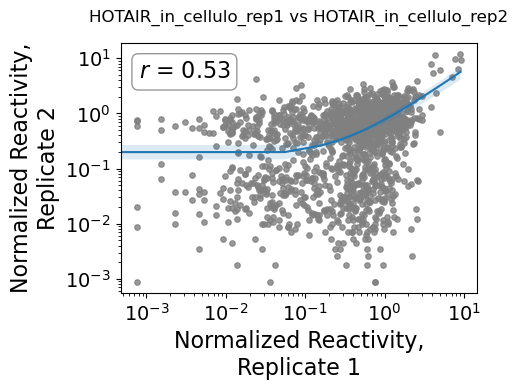

In [11]:
pairs_to_plot = [('HOTAIR_in_cellulo_rep1', 'HOTAIR_in_cellulo_rep2')]

results = []

# Compute correlations
for s1, s2 in pairs_to_plot:
    x = data_dict[s1]['Norm_profile']
    y = data_dict[s2]['Norm_profile']
    mask = x.notna() & y.notna() & (x<19.9) & (y<19.9)
    # mask = x.notna() & y.notna()
    if len(x[mask]) > 1 and np.std(x[mask]) > 0 and np.std(y[mask]) > 0:
        pearson_r, pearson_p = pearsonr(x[mask], y[mask])
        spearman_r, spearman_p = spearmanr(x[mask], y[mask])
    else:
        pearson_r = pearson_p = spearman_r = spearman_p = np.nan  # skip this pair
    results.append({'sample_i': s1,'sample_j': s2,'x': x[mask],'y': y[mask],'pearson_r': pearson_r,'pearson_p': pearson_p,'spearman_r': spearman_r,'spearman_p': spearman_p})
    print(f"{s1}_vs_{s2}")
    print(f"  Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
    print(f"  Spearman ρ = {spearman_r:.3f}, p = {spearman_p:.3e}\n")

# Plot
for result in results:
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.regplot(x=result['x'], y=result['y'], ax=ax, scatter_kws={'s': 15,'color': 'gray'}, line_kws={'color': '#1f77b4', 'linewidth': 1.5})
    ax.set_title(f"{result['sample_i']} vs {result['sample_j']}",fontsize='12', pad=15)
    ax.set_xlabel('Normalized Reactivity,\nReplicate 1', fontsize='16')
    ax.set_ylabel('Normalized Reactivity,\nReplicate 2', fontsize='16')
    ax.text(0.05, 0.93, f"$r$ = {result['pearson_r']:.2f}",
            transform=ax.transAxes, fontsize=16, va='top',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    # ax.text(0.1, 0.78, f"$ρ$ = {result['spearman_r']:.2f}",
    #         transform=ax.transAxes, fontsize=14, va='top',
    #         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    ax.tick_params(axis='both', labelsize=14, colors='black')
    # ax.xaxis.set_major_locator(MultipleLocator(10))
    # ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.set_xscale('log')
    ax.set_yscale('log')

    plt.tight_layout()
    # plt.savefig(f"INSERT/PATH/TO/SAVE/{result['sample_i']}_vs_{result['sample_j']}_Pearson_remove4_logscale.png", dpi=300)
    plt.show()

### Modified vs. Untreated Rates

2.4779945062026904e-228
Modified mean: 0.0030928086102012167 std: 0.03595854560096134
Unmodified mean: 0.001576295058823529 std: 0.027424094076868615


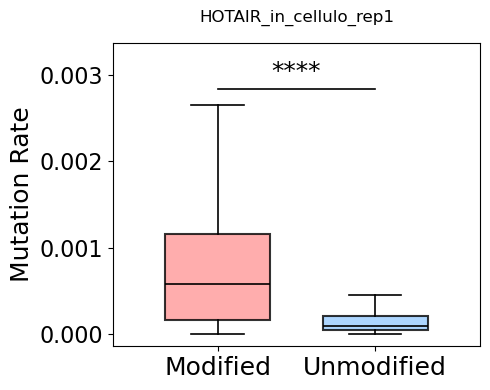

2.0223269927608055e-163
Modified mean: 0.003081269915651359 std: 0.04251575307345792
Unmodified mean: 0.002532372539831303 std: 0.04271357514513305


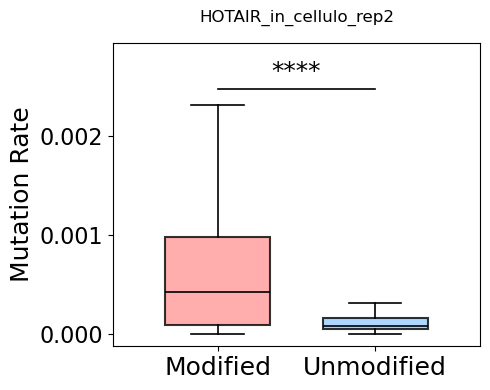

2.9748180693917822e-288
Modified mean: 0.012982516917293232 std: 0.028964647255978235
Unmodified mean: 0.0014649622905027935 std: 0.0041881373031226


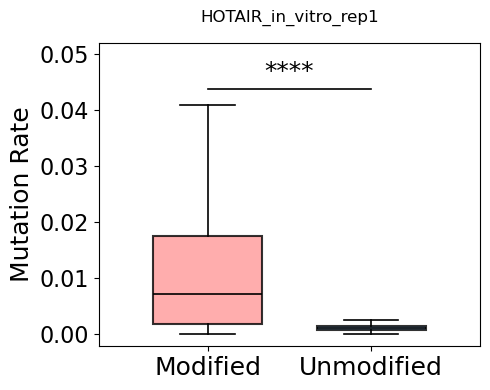

1.000282489559549e-287
Modified mean: 0.011790982209737828 std: 0.019636479623100663
Unmodified mean: 0.0015067858472998137 std: 0.00422064718815886


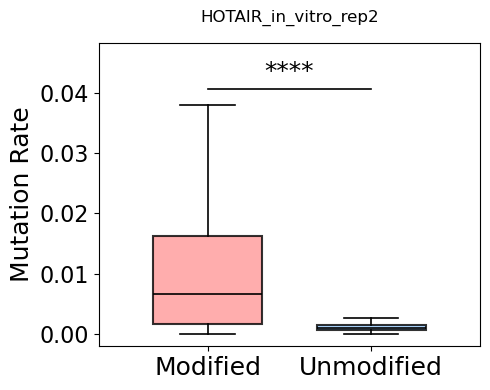

2.658502042580858e-17
Modified mean: 0.005712744331508991 std: 0.03656932544929661
Unmodified mean: 0.0027968136503067485 std: 0.03386746001065629


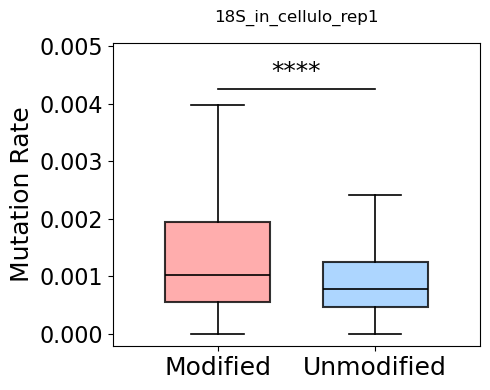

2.2059386922587594e-17
Modified mean: 0.005815326578332034 std: 0.03669424354235797
Unmodified mean: 0.003126951538461538 std: 0.03386188848352567


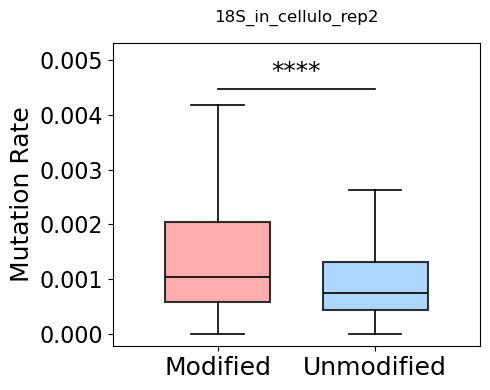

In [14]:
samples = ['HOTAIR_in_cellulo_rep1', 'HOTAIR_in_cellulo_rep2',
    'HOTAIR_in_vitro_rep1', 'HOTAIR_in_vitro_rep2',
    '18S_in_cellulo_rep1', '18S_in_cellulo_rep2']

for sample in samples:
    # Extract data and drop NaNs
    mod = data_dict[sample]['Modified_rate'].dropna()
    unmod = data_dict[sample]['Untreated_rate'].dropna()
    data = [mod, unmod]
    positions = [0, 0.15]

    # Create new figure for each sample
    fig, ax = plt.subplots(figsize=(5, 4))

    # Boxplot
    bp = ax.boxplot(
        data, positions=positions, widths=0.1, patch_artist=True, showfliers=False,
        boxprops=dict(edgecolor='black', linewidth=1.5),
        medianprops=dict(color='black', linewidth=1.2),
        whiskerprops=dict(color='black', linewidth=1.2),
        capprops=dict(color='black', linewidth=1.2)
    )

    # Box colors
    colors = ["#FF9999", "#99CCFF"]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # Formatting
    ax.set_title(f'{sample}', fontsize=12, pad=15)
    ax.set_xticks(positions)
    ax.set_xticklabels(["Modified", "Unmodified"], fontsize=18)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_ylabel("Mutation Rate", fontsize=18)
    ax.set_xlim(-0.1, 0.25)

    # T-test
    stat, p = mannwhitneyu(mod, unmod, alternative='two-sided') # nonparametric test best captures skewed distribution with high variance
    if p <= 0.0001:
        significance = '****'
    elif p <= 0.001:
        significance = '***'
    elif p <= 0.01:
        significance = '**'
    elif p <= 0.05:
        significance = '*'
    else:
        significance = 'ns'

    print(p)
    print("Modified mean:", np.mean(mod), "std:", np.std(mod))
    print("Unmodified mean:", np.mean(unmod), "std:", np.std(unmod))

    # Get whisker tops
    whisker_tops = [line.get_ydata()[1] for j, line in enumerate(ax.lines) if j in [1, 3]]
    y_max = max(whisker_tops)
    line_y = y_max + 0.07 * y_max

    # Significance bar and label
    ax.plot(positions, [line_y, line_y], color='black', linewidth=1.2)
    ax.text(sum(positions)/2, line_y + 0.02 * y_max, significance,
            ha='center', va='bottom', fontsize=18)

    # Adjust y-limits
    current_ylim = ax.get_ylim()
    ax.set_ylim(current_ylim[0], line_y + 0.2 * y_max)
    # ax.set_yticks([0.000, 0.001, 0.002, 0.003])

    plt.tight_layout()
    # Optionally save each sample’s plot separately
    # plt.savefig(f"INSERT/PATH/TO/SAVE/{sample}_Mutation_Rate_Boxplot.png", dpi=300, bbox_inches='tight')
    plt.show()

### dsRNA/ssRNA Grouping

In [19]:
samples = ['HOTAIR_in_cellulo_rep1', 'HOTAIR_in_cellulo_rep2', 'HOTAIR_in_cellulo_avg',
 'HOTAIR_in_vitro_rep1', 'HOTAIR_in_vitro_rep2', 'HOTAIR_in_vitro_avg']

3.687079152069678e-14
ssRNA mean: 0.7545206722164413 std: 2.6244531131490003
dsRNA mean: 0.3549019684684685 std: 0.4664084341600818


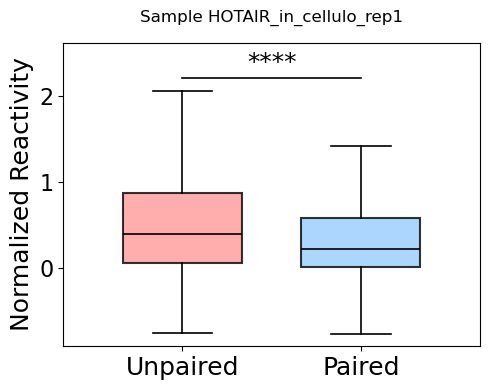

5.643597545830356e-15
ssRNA mean: 0.7630239634801289 std: 2.61428832857818
dsRNA mean: 0.31769258245614035 std: 0.4796563453542211


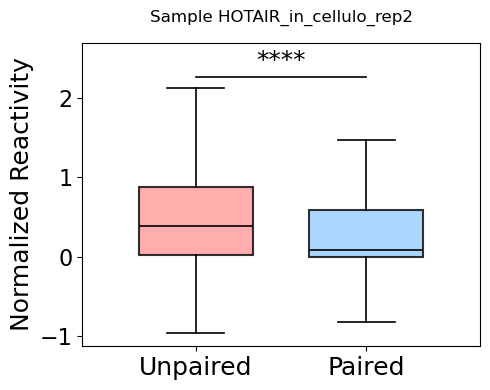

2.0068658959109438e-11
ssRNA mean: 0.7282836769230769 std: 2.5467458438567023
dsRNA mean: 0.35192848312043795 std: 0.3597105016421818


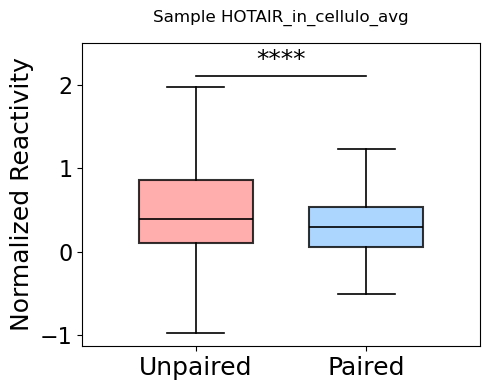

0.001070986370315271
ssRNA mean: 0.5922755493250258 std: 0.7159522185680766
dsRNA mean: 0.35720477351598173 std: 0.3855488080166044


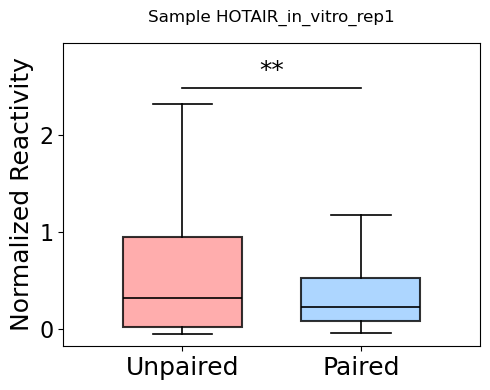

0.0007575331383138688
ssRNA mean: 0.5876671578400832 std: 0.7051740129844093
dsRNA mean: 0.36045138524590165 std: 0.3940247215955629


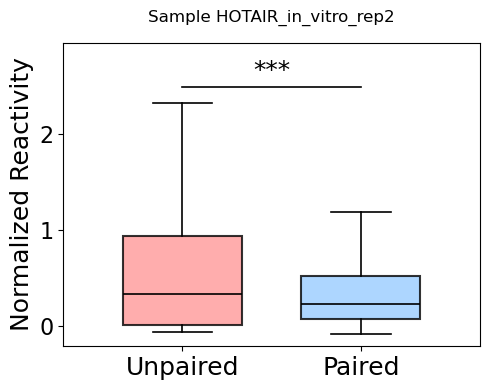

0.0009665683910161378
ssRNA mean: 0.5900936137316563 std: 0.7089978780083616
dsRNA mean: 0.36019596829710143 std: 0.3924832159542578


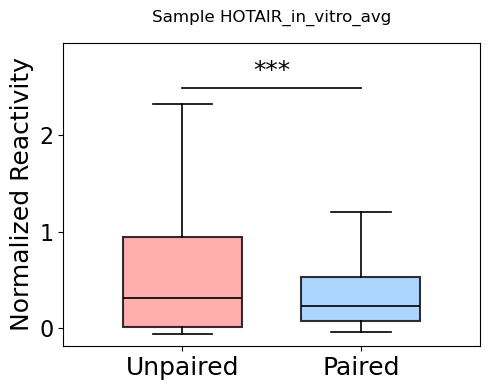

In [20]:
for sample in samples:

    # Group based on base-pairing
    unpaired = data_dict[sample].loc[data_dict[sample]['Base_pair'] == 0, 'Norm_profile'].dropna()
    paired = data_dict[sample].loc[data_dict[sample]['Base_pair'] > 0, 'Norm_profile'].dropna()
    data = [unpaired, paired]
    positions = [0, 0.15]

    # Create new figure for each sample
    fig, ax = plt.subplots(figsize=(5, 4))

    # Plot with matplotlib's boxplot
    bp = ax.boxplot(data, positions=positions, widths=0.1, patch_artist=True, showfliers=False,
        boxprops=dict(edgecolor='black', linewidth=1.5),
        medianprops=dict(color='black', linewidth=1.2),
        whiskerprops=dict(color='black', linewidth=1.2),
        capprops=dict(color='black', linewidth=1.2)
    )

    # Set box colors
    colors = ["#FF9999", "#99CCFF"]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # Formatting
    ax.set_title(f'Sample {sample}', fontsize=12, pad=15)
    ax.set_xticks(positions) # set xtick locations
    ax.set_xticklabels(["Unpaired", "Paired"], fontsize=18)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("Normalized Reactivity", fontsize=18)
    ax.set_xlim(-0.1, 0.25)
    
    # Add p-value
    stat, p = mannwhitneyu(unpaired, paired, alternative='two-sided')
    significance = '****' if p <= 0.0001 else '***' if p <= 0.001 else '**' if p <= 0.01 else '*' if p <= 0.05 else 'ns'

    print(p)
    print("ssRNA mean:", np.mean(unpaired), "std:", np.std(unpaired))
    print("dsRNA mean:", np.mean(paired), "std:", np.std(paired))
    
    # Top whisker for each box
    whisker_lines = [line.get_ydata()[1] for j, line in enumerate(ax.lines) if j in [1, 4]]
    max_whisker = max(whisker_lines)
    line_y = max_whisker + 0.07 * max_whisker

    # Draw significance line and asterisk
    ax.plot(positions, [line_y, line_y], color='black', linewidth=1.2)
    ax.text(sum(positions)/2, line_y + 0.02 * max_whisker, significance, ha='center', va='bottom', fontsize=18)

    # Adjust y-limits
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, line_y + 0.2 * max_whisker)
    
    plt.tight_layout()
    # plt.savefig(f"INSERT/PATH/TO/SAVE/{sample}_unpaired_paired.png", dpi=300, bbox_inches='tight')
    plt.show()

#### Exploratory Analysis: Segment RNA by reactivities in low vs. medium vs. high reactivity regions

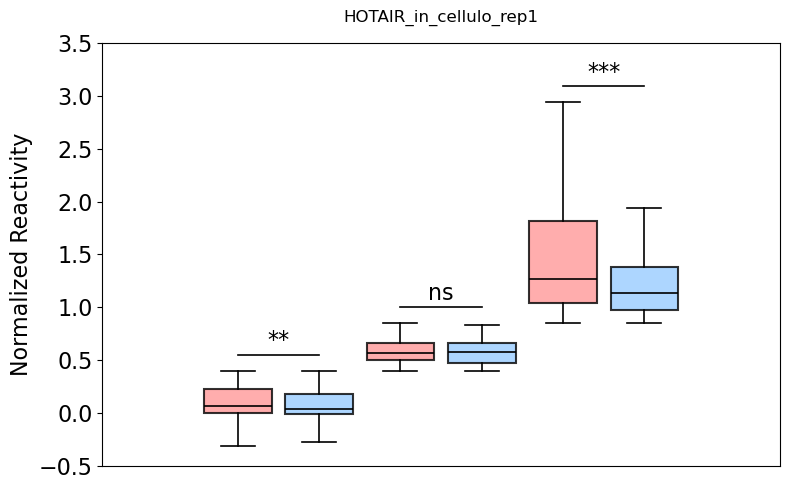

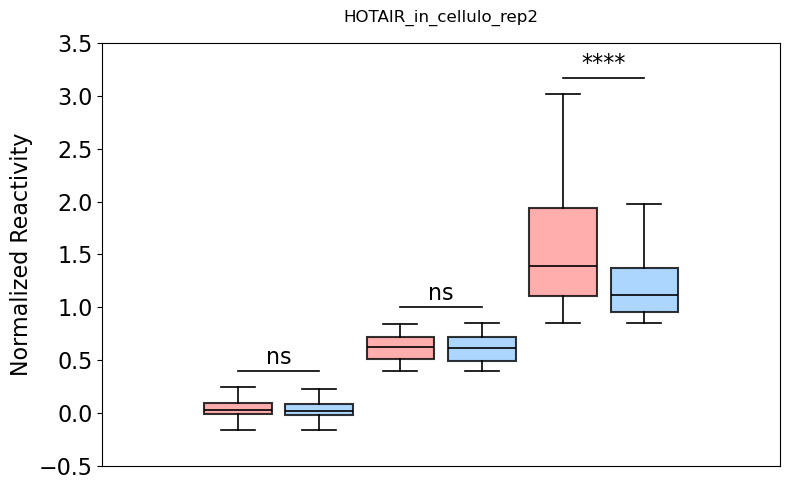

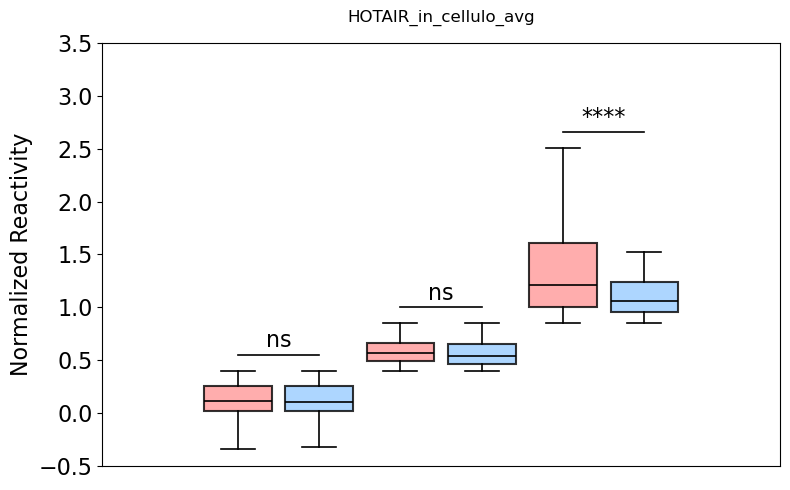

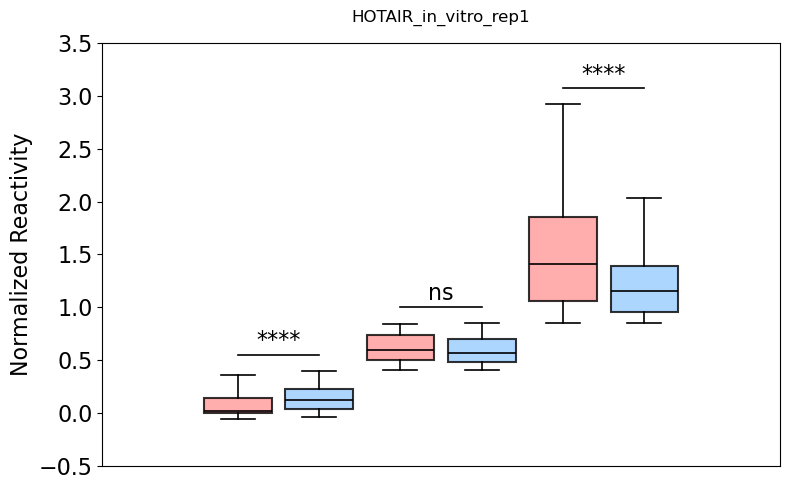

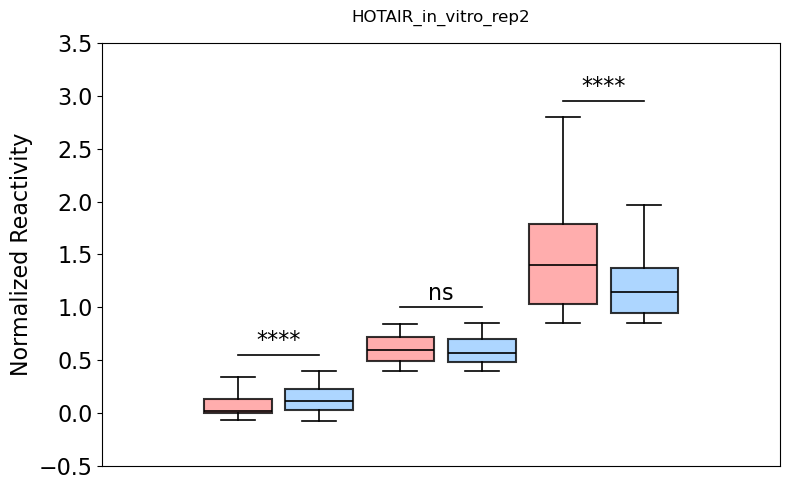

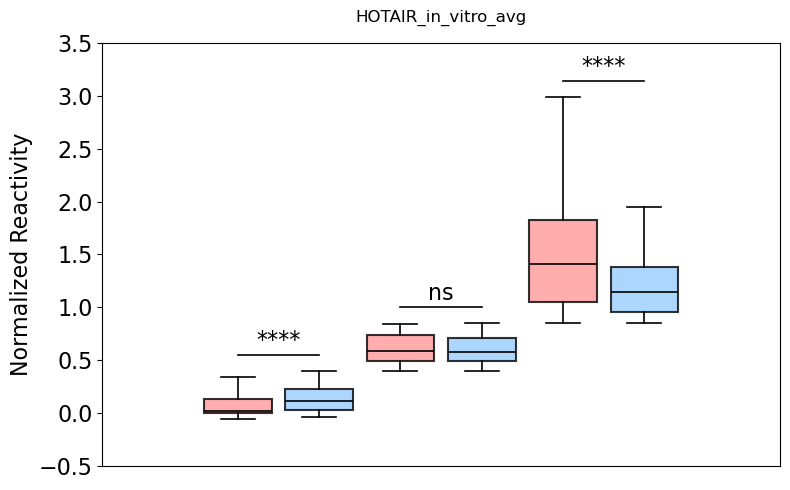

In [21]:
# Define category cutoffs for reactivity
high_cutoff = 0.85
low_cutoff  = 0.40

for sample in samples:

    df = data_dict[sample].dropna(subset=['Norm_profile', 'Base_pair'])

    # Define reactivity bins
    low_mask = df['Norm_profile'] < low_cutoff
    med_mask = (df['Norm_profile'] >= low_cutoff) & (df['Norm_profile'] < high_cutoff)
    high_mask = df['Norm_profile'] >= high_cutoff

    categories = {'Low': low_mask,'Medium': med_mask,'High': high_mask}

    # Store for plotting
    data = []
    labels = []
    colors = []

    color_map = {"Unpaired": "#FF9999", "Paired": "#99CCFF"}

    # Iterate over categories
    for cat_name, mask in categories.items():
        unpaired = df.loc[mask & (df['Base_pair'] == 0), 'Norm_profile']
        paired   = df.loc[mask & (df['Base_pair'] > 0), 'Norm_profile']

        # Skip empty bins
        if len(unpaired) < 2 or len(paired) < 2:
            print(f"Skipping {sample} - {cat_name} (not enough data)")
            continue

        data.extend([unpaired, paired])
        labels.extend([f"{cat_name}\nUnpaired", f"{cat_name}\nPaired"])
        colors.extend([color_map["Unpaired"], color_map["Paired"]])

    # Create new figure for each sample
    fig, ax = plt.subplots(figsize=(8, 5))
    positions = np.arange(len(data)) * 0.3

    # Plot with matplotlib's boxplot
    bp = ax.boxplot(data, positions=positions, widths=0.25, patch_artist=True, showfliers=False,
        boxprops=dict(edgecolor='black', linewidth=1.5),
        medianprops=dict(color='black', linewidth=1.2),
        whiskerprops=dict(color='black', linewidth=1.2),
        capprops=dict(color='black', linewidth=1.2)
    )

    # Set box colors
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # Formatting
    ax.set_title(f'{sample}', fontsize=12, pad=15)
    # ax.set_xticks(positions) # set xtick locations
    # ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("Normalized Reactivity", fontsize=16)
    ax.set_ylim(-0.5, 3.5)
    # Remove x-axis labels and ticks
    ax.set_xticks([])     # removes tick marks
    ax.set_xticklabels([])  # removes tick labels
    
    # Each box has 2 whiskers (bottom, top): take every second one starting from index 1
    top_whiskers = [w.get_ydata()[1] for w in bp['whiskers'][1::2]]

    # P value
    for i, cat_name in enumerate(categories.keys()): # find proper groups to compare in "data"
        idx_unpaired = i * 2
        idx_paired = idx_unpaired + 1
        if idx_paired >= len(data):  # skip missing category
            continue

        unpaired = data[idx_unpaired]
        paired = data[idx_paired]

        stat, p = mannwhitneyu(unpaired, paired, alternative='two-sided')
        sig = '****' if p <= 0.0001 else '***' if p <= 0.001 else '**' if p <= 0.01 else '*' if p <= 0.05 else 'ns'

        # Get whisker tops for the pair
        y_unpaired = top_whiskers[idx_unpaired]
        y_paired = top_whiskers[idx_paired]

        # Use fixed offset above taller whisker
        offset = 0.15
        line_y = max(y_unpaired, y_paired) + offset
        
        # Add significance line above each pair
        ax.plot([positions[idx_unpaired], positions[idx_paired]], [line_y, line_y], color='black', linewidth=1.2)
        ax.text(np.mean([positions[idx_unpaired], positions[idx_paired]]), line_y + 0.01*y_max, sig,
                    ha='center', va='bottom', fontsize=16)
    
    plt.tight_layout()
    # plt.savefig(f"INSERT/PATH/TO/SAVE/{sample}_ssRNA_dsRNA_binned.png", dpi=300, bbox_inches='tight')
    plt.show()

#### Exploratory Analysis: Segment RNA by structured vs. flexible regions (Shannon entropy cutoff)

0.134823333508


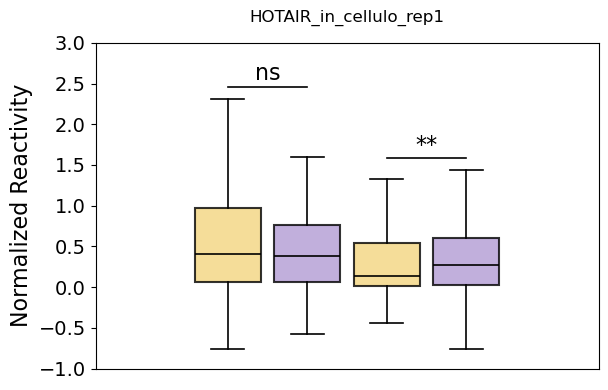

0.161841265921


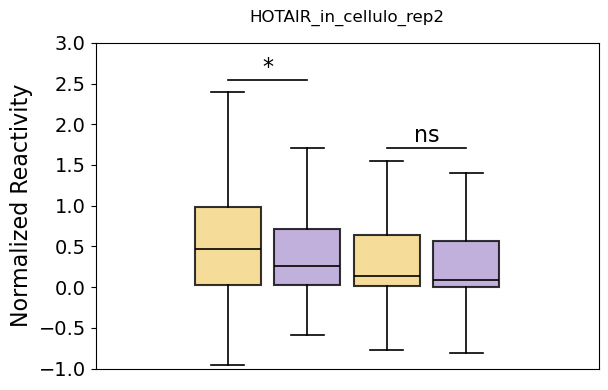

0.159949121992


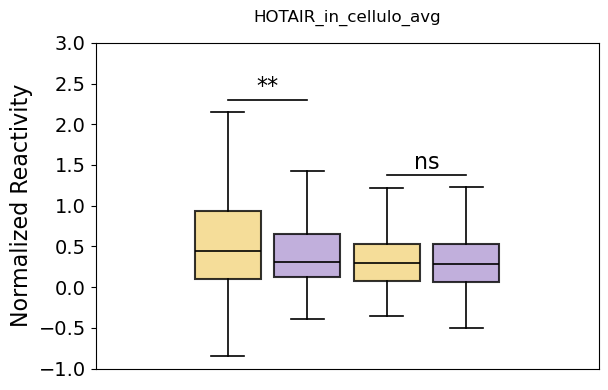

0.1282698558325


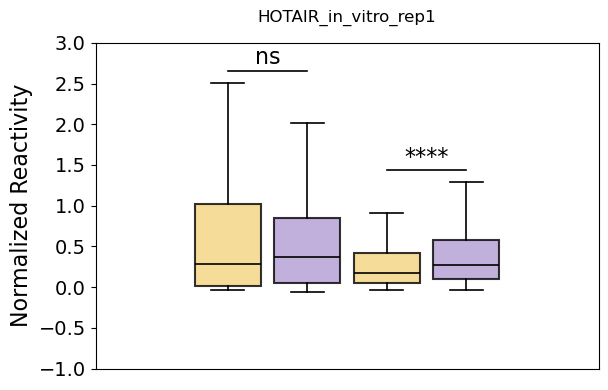

0.116860133679


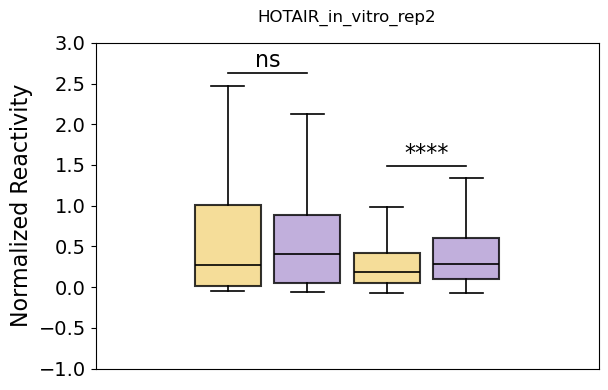

0.128655432683


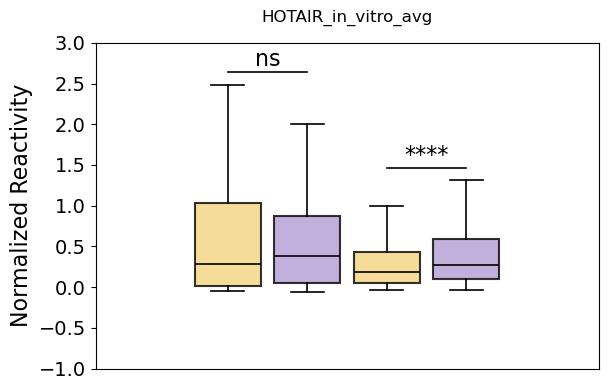

In [22]:
for sample in samples:

    # Drop NaNs for relevant columns
    df = data_dict[sample].dropna(subset=['Norm_profile', 'Base_pair', 'Shannon'])

    # Compute global median of Shannon entropy
    global_median_shannon = df['Shannon'].median()
    print(global_median_shannon)

    # Define Shannon entropy bins
    low_entropy_mask  = df['Shannon'] < global_median_shannon
    high_entropy_mask = df['Shannon'] >= global_median_shannon
    categories = {'Low Shannon': low_entropy_mask, 'High Shannon': high_entropy_mask}

    # Store for plotting
    data = []
    labels = []
    colors = []
    color_map = {"Unpaired": "#FF9999", "Paired": "#99CCFF"}

    # Collect data into separate dicts first
    unpaired_data = {}
    paired_data = {}

    # Iterate over categories
    for cat_name, mask in categories.items():
        unpaired = df.loc[mask & (df['Base_pair'] == 0), 'Norm_profile']
        paired   = df.loc[mask & (df['Base_pair'] > 0), 'Norm_profile']
    
        # Skip empty bins
        if len(unpaired) >= 2:
            unpaired_data[cat_name] = unpaired
        if len(paired) >= 2:
            paired_data[cat_name] = paired
    
    # Control order
    data = [
        unpaired_data.get('Low Shannon', pd.Series(dtype=float)),
        unpaired_data.get('High Shannon', pd.Series(dtype=float)),
        paired_data.get('Low Shannon', pd.Series(dtype=float)),
        paired_data.get('High Shannon', pd.Series(dtype=float))
    ]
    
    labels = ['Low\nUnpaired', 'High\nUnpaired', 'Low\nPaired', 'High\nPaired']
    colors = ['#F3D580', '#B29BD4', '#F3D580', '#B29BD4']

    # Create new figure for each sample
    fig, ax = plt.subplots(figsize=(6, 4))
    positions = np.arange(len(data)) * 0.3

    # Plot with matplotlib's boxplot
    bp = ax.boxplot(
        data, positions=positions, widths=0.25, patch_artist=True, showfliers=False,
        boxprops=dict(edgecolor='black', linewidth=1.5),
        medianprops=dict(color='black', linewidth=1.2),
        whiskerprops=dict(color='black', linewidth=1.2),
        capprops=dict(color='black', linewidth=1.2)
    )

    # Set box colors
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # Formatting
    ax.set_title(f'{sample}', fontsize=12, pad=15)
    ax.set_ylabel("Normalized Reactivity", fontsize=16)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_xlabel("")
    ax.set_ylim(-1.0, 3.0)  # adjust manually if needed

    # Calculate significance of paired vs. paired and unpaired vs. unpaired within each Shannon bin
    top_whiskers = [w.get_ydata()[1] for w in bp['whiskers'][1::2]]
    offset = 0.15

    # Calculate significance
    # UNPAIRED
    if len(data[0]) > 1 and len(data[1]) > 1:
        stat, p = mannwhitneyu(data[0], data[1], alternative='two-sided')
        sig_unpaired = '****' if p <= 0.0001 else '***' if p <= 0.001 else '**' if p <= 0.01 else '*' if p <= 0.05 else 'ns'
    
        y_low, y_high = top_whiskers[0], top_whiskers[1]
        line_y = max(y_low, y_high) + offset
        ax.plot([positions[0], positions[1]], [line_y, line_y], color='black', linewidth=1.2)
        ax.text(np.mean([positions[0], positions[1]]), line_y + offset * 0.1, sig_unpaired,
                ha='center', va='bottom', fontsize=16)

    # PAIRED
    if len(data[2]) > 1 and len(data[3]) > 1:
        stat, p = mannwhitneyu(data[2], data[3], alternative='two-sided')
        sig_paired = '****' if p <= 0.0001 else '***' if p <= 0.001 else '**' if p <= 0.01 else '*' if p <= 0.05 else 'ns'
    
        y_low, y_high = top_whiskers[2], top_whiskers[3]
        line_y = max(y_low, y_high) + offset
        ax.plot([positions[2], positions[3]], [line_y, line_y], color='black', linewidth=1.2)
        ax.text(np.mean([positions[2], positions[3]]), line_y + offset * 0.1, sig_paired,
                ha='center', va='bottom', fontsize=16)

    plt.tight_layout()
    # plt.savefig(f"INSERT/PATH/TO/SAVE/{sample}_ssRNA_dsRNA_Shannon.png", dpi=300, bbox_inches='tight')
    plt.show()

### Reactivity-Shannon Analysis of Structured Regions

#### Functions

In [23]:
# Plotting function for consistent formatting
def line_plot(x: pd.Series, y: pd.DataFrame=None, plot_title: str=None, plot_y_label: str=None, color: str='black', linewidth: float=1.2, label: str=None, overlay: bool=False, show: bool=True,
             y2: pd.Series=None, y2_axis_label: str=None, y2_color: str='blue', y2_label: str=None, y2_ax=None, add_legend: bool=False):
    
    if not overlay:
        # Set seaborn style
        sns.set_theme(
            style="ticks",
            context="talk",
            font="Arial",
            font_scale=1.0,
            rc={
                "axes.edgecolor": "black",
                "axes.linewidth": 1.2,
                "axes.titlesize": 14,
                "axes.labelsize": 14,
                "xtick.major.size": 5,
                "ytick.major.size": 5,
                "xtick.direction": "out",
                "ytick.direction": "out",
                "axes.labelsize": 16
            }
            )
        fig, ax1 = plt.subplots(figsize=(14, 4))
    else:
        ax1 = plt.gca()

    if y is not None:
        # Plot primary series if provided
        ax1.plot(x, y, linewidth=linewidth, color=color, label=label, alpha=0.9)
        ax1.set_ylabel(plot_y_label)
        ax1.tick_params(axis='y')

    # Add secondary axis if provided
    if y2 is not None:
        if y2_ax is None:
            y2_ax = ax1.twinx()
        y2_ax.plot(x, y2, linewidth=linewidth, color=y2_color, label=y2_label, alpha=0.9)
        y2_ax.set_ylabel(y2_axis_label)
        y2_ax.tick_params(axis='y')

    if not overlay:
        # Add grid, labels, title
        ax1.grid(True, alpha=0.2, linestyle='--')
        ax1.set_title(plot_title, fontsize=14,pad=15)
        ax1.set_xlabel('Nucleotide')

    if add_legend:
        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = y2_ax.get_legend_handles_labels() if y2_ax else ([], [])
        # Display legends
        ax1.legend(handles1, labels1, loc='upper left', bbox_to_anchor=(0, -0.25), frameon=True, fancybox=True)
        if y2_ax:
            y2_ax.legend(handles2, labels2, loc='upper right', bbox_to_anchor=(1, -0.25), frameon=True, fancybox=True)

    if show and not overlay:
        # Tight layout and show
        plt.tight_layout()
        plt.show()
        

In [24]:
# Function for RS Analysis
def get_lowSS_regions(df: pd.DataFrame,
    nuc_col: str,
    r_col: str,
    s_col: str,
    r_global_median: float,
    s_global_median: float,
    min_region_length: int = 40,
    lowSS: bool=True,
    lowSHAPE: bool=False) -> list:
   
    """
    Finds regions where the difference between the sliding median and the global median is above or below a threshold for a minimum nucleotide length. 

    Parameters:
        df (pd.DataFrame): Input dataframe
        nuc_col (str): Column name for x-axis ('Nucleotide')
        r_col (str): Reactivities
        s_col (str): Shannon entropies
        r_global_median (float): Threshold for reactivity
        s_global_median (float): Threshold for Shannon entropy
        min_region_length (int): Minimum length
        lowSS (bool): If true, find regions with both low reactivity and low Shannon; otherwise find low reactivity and high Shannon
        lowSHAPE (bool): If false, analyze both reactivity and Shannon; if true, only return low SHAPE regions

    Returns:
        Tuple:
            regions (List[Tuple[int, int]]): List of (x_start, x_end) nucleotide regions to highlight
            delta_r (pd.Series): Difference between sliding and global median for Reactivity
            delta_s (pd.Series): Difference between sliding and global median for Shannon entropy
    """
    # calculate difference between sliding medians and the global median
    delta_r = df[r_col] - r_global_median
    delta_s = df[s_col] - s_global_median
    
    # compare to zero
    if lowSS and not lowSHAPE:
        condition = (delta_r < 0) & (delta_s < 0)
    elif not lowSS and not lowSHAPE:
        condition = (delta_r < 0) & (delta_s > 0)
    else:
        condition = (delta_r < -0.02)
        
    mask = condition.to_numpy()

    regions = []
    in_region = False

    for i, val in enumerate(mask):
        if val and not in_region:
            start = i
            in_region = True
        elif not val and in_region:
            end = i - 1
            if end - start + 1 >= min_region_length:
                x_start = df[nuc_col].iloc[start]
                x_end = df[nuc_col].iloc[end]
                regions.append((x_start, x_end))
            in_region = False

    if in_region:
        end = len(mask) - 1
        if end - start + 1 >= min_region_length:
            x_start = df[nuc_col].iloc[start]
            x_end = df[nuc_col].iloc[end]
            regions.append((x_start, x_end))

    return regions, delta_r, delta_s


In [25]:
def sliding_windows(df, window_size, step_size, columns=None, agg_func=None, seq_func=None, window_func=None):
    """
    Apply a sliding window across nucleotide rows in a DataFrame and compute a summary statistic
    (e.g., median) for specified columns. Associates result with the center nucleotide of each window.

    Parameters:
        df (pd.DataFrame): DataFrame where each row corresponds to a nucleotide
        columns (list of str): List of column names to apply the aggregation function to.
        window_size (int): Size of the sliding window (should be odd for symmetry)
        step_size (int): Number of rows to move the window by each time
        agg_func (function): Aggregation function to apply (e.g., np.median, np.mean, custom function)
        seq_func (function): Function to calculate sequence-specific properties

    Returns:
        pd.DataFrame: A DataFrame with one row per center nucleotide
    """
    
    # Check that window size is odd
    assert window_size % 2 == 1, "Window size must be odd."
    half_window = (window_size + 1) // 2 # For 51nt windows, half_window=26
    
    # Initialize list
    result = []

    # Get nucleotides for looping
    nts = df['Nucleotide'].unique()
    nts.sort()
    max_nt = df['Nucleotide'].max()
    
    # Loop through dataframe, incrementing by the step_size
    for i in range(0, len(nts), step_size):
        # Define window range (truncate at boundaries)
        center = nts[i]
        # Full-length window start/end nts
        full_start = 1 + half_window - 1 # 1 + 26 - 1 = 26
        full_end = max_nt - half_window + 1 # 2116 - 26 + 1 = 2091
        # Beginning windows
        if center <= full_end:
            start = max(1, center - half_window + 1) # max(1,1-26+1) = 1, # max(1,26-26+1) = 1 # max(1,27-26+1) = 2
            end = min(max_nt, center + half_window - 1) # min(2116,1+26-1) = 26, # min(2116,26+26-1) = 51 # min(2116,27+26-1) = 52
        # Decreasing truncated windows at end
        elif center > full_end:
            start = max(1, center - half_window + 1) # max(1,2092-26+1)=2067
            end = min(max_nt, center + half_window - 2) #(2116,2092+26-2)=2116

        window = df[(df['Nucleotide'] >= start) & (df['Nucleotide'] <= end)]

        # print(f"Center: {center}, Window range: {start}-{end}")
        # print(df[(df['Nucleotide'] >= start) & (df['Nucleotide'] <= end)][['Nucleotide', 'Shannon']])
        
        # Initialize dict
        summary = {}
        
        if columns and agg_func:
            # Calculate aggregate values for each column in the window
            for col in columns:
                valid_vals = window[col].dropna()
                if len(valid_vals) >= half_window:
                    summary[col] = agg_func(valid_vals)
                else:
                    summary[col] = np.nan

        # Apply custom window functions
        if window_func:
            window_result = window_func(window)
            summary.update(window_result)
        
        # Optional: Sequence-based metrics
        if seq_func is not None and 'Sequence' in df.columns:
            sequence = ''.join(window['Sequence'].astype(str)).upper()
            summary[seq_func.__name__] = seq_func(sequence)
        
        summary['Nucleotide'] = center
        summary['CenterIndex'] = i
        result.append(summary)

    return pd.DataFrame(result)


#### Plotting

In [29]:
df = data_dict['HOTAIR_in_cellulo_avg']
df.head()

,Nucleotide,Sequence,Norm_profile,Base_pair,Shannon
0,1,g,NaN,0,0.006313
1,2,a,NaN,0,0.008690
2,3,c,NaN,428,0.523165
3,4,u,NaN,427,0.632966
4,5,c,NaN,426,0.640268


In [30]:
# Loop through all samples and calculate the sliding median
window_size = 51 # nucleotides
for sample, df in data_dict.items():
    df_copy = df.copy()
    if 'Norm_profile' in df_copy.columns:
        df_copy['Sliding_median_reactivity'] = df_copy['Norm_profile'].rolling(window=window_size, center=True, min_periods=1).median() # truncated windows at edges
        data_dict[sample] = df_copy  # update back into dict

In [31]:
df = data_dict['HOTAIR_in_cellulo_avg']
df.head()

,Nucleotide,Sequence,Norm_profile,Base_pair,Shannon,Sliding_median_reactivity
0,1,g,NaN,0,0.006313,NaN
1,2,a,NaN,0,0.008690,0.252636
2,3,c,NaN,428,0.523165,0.166097
3,4,u,NaN,427,0.632966,0.252636
4,5,c,NaN,426,0.640268,0.166097


In [32]:
# Loop through all samples and calculate the sliding median
window_size = 51 # nucleotides
for sample, df in data_dict.items():
    df_copy = df.copy()
    if 'Shannon' in df.columns:
        df_copy['Sliding_median_shannon'] = df_copy['Shannon'].rolling(window=window_size, center=True, min_periods=1).median() # truncated windows at edges
        data_dict[sample] = df_copy  # update back into dict

In [33]:
df = data_dict['HOTAIR_in_cellulo_avg']
df.head()

,Nucleotide,Sequence,Norm_profile,Base_pair,Shannon,Sliding_median_reactivity,Sliding_median_shannon
0,1,g,NaN,0,0.006313,NaN,0.352591
1,2,a,NaN,0,0.008690,0.252636,0.382552
2,3,c,NaN,428,0.523165,0.166097,0.377079
3,4,u,NaN,427,0.632966,0.252636,0.371606
4,5,c,NaN,426,0.640268,0.166097,0.347118


In [34]:
# Calculate per sample global medians

global_medians_reactivity = {}
global_medians_shannon = {}

for sample in samples:
    # Drop rows if one column is NaN (consistent with box plots)
    df_full = data_dict[sample]
    n_total = len(df_full)
    df = data_dict[sample].dropna(subset=['Norm_profile', 'Base_pair', 'Shannon'])
    n_kept = len(df)

    n_dropped = n_total - n_kept
    frac_dropped = n_dropped / n_total * 100
    print(f"{sample}: Dropped {n_dropped} of {n_total} nucleotides ({frac_dropped:.1f}%) due to missing values.")


    # Reactivity median
    if 'Norm_profile' in df.columns:
        median_val = df['Norm_profile'].median()
        global_medians_reactivity[sample] = median_val
        print(f"{sample} Reactivity : {median_val:.4f}")

    # Shannon median
    if 'Shannon' in df.columns:
        median_val = df['Shannon'].median()
        global_medians_shannon[sample] = median_val
        print(f"{sample} Shannon : {median_val:.4f}\n")

HOTAIR_in_cellulo_rep1: Dropped 77 of 2148 nucleotides (3.6%) due to missing values.
HOTAIR_in_cellulo_rep1 Reactivity : 0.3114
HOTAIR_in_cellulo_rep1 Shannon : 0.1348

HOTAIR_in_cellulo_rep2: Dropped 77 of 2148 nucleotides (3.6%) due to missing values.
HOTAIR_in_cellulo_rep2 Reactivity : 0.1993
HOTAIR_in_cellulo_rep2 Shannon : 0.1618

HOTAIR_in_cellulo_avg: Dropped 77 of 2148 nucleotides (3.6%) due to missing values.
HOTAIR_in_cellulo_avg Reactivity : 0.3305
HOTAIR_in_cellulo_avg Shannon : 0.1599

HOTAIR_in_vitro_rep1: Dropped 90 of 2148 nucleotides (4.2%) due to missing values.
HOTAIR_in_vitro_rep1 Reactivity : 0.2625
HOTAIR_in_vitro_rep1 Shannon : 0.1283

HOTAIR_in_vitro_rep2: Dropped 87 of 2148 nucleotides (4.1%) due to missing values.
HOTAIR_in_vitro_rep2 Reactivity : 0.2617
HOTAIR_in_vitro_rep2 Shannon : 0.1169

HOTAIR_in_vitro_avg: Dropped 90 of 2148 nucleotides (4.2%) due to missing values.
HOTAIR_in_vitro_avg Reactivity : 0.2635
HOTAIR_in_vitro_avg Shannon : 0.1287



In [35]:
df = data_dict['HOTAIR_in_cellulo_avg']
stdev = df['Norm_profile'].std()
print(stdev)

1.7772944239645256


In [36]:
df = data_dict['HOTAIR_in_cellulo_avg']
df.head()

,Nucleotide,Sequence,Norm_profile,Base_pair,Shannon,Sliding_median_reactivity,Sliding_median_shannon
0,1,g,NaN,0,0.006313,NaN,0.352591
1,2,a,NaN,0,0.008690,0.252636,0.382552
2,3,c,NaN,428,0.523165,0.166097,0.377079
3,4,u,NaN,427,0.632966,0.252636,0.371606
4,5,c,NaN,426,0.640268,0.166097,0.347118


In [37]:
samples = ['HOTAIR_in_cellulo_avg', 'HOTAIR_in_vitro_avg']


Sample HOTAIR_in_cellulo_avg
2071
2071 {'Nucleotide': 0, 'Sliding_median_reactivity': 0, 'Sliding_median_shannon': 0}
Low Regions: Sample HOTAIR_in_cellulo_avg: [(547, 588), (596, 645), (788, 869), (1408, 1457), (2006, 2058)]
High Regions: Sample HOTAIR_in_cellulo_avg: [(27, 182), (224, 301), (336, 414), (942, 1007)]


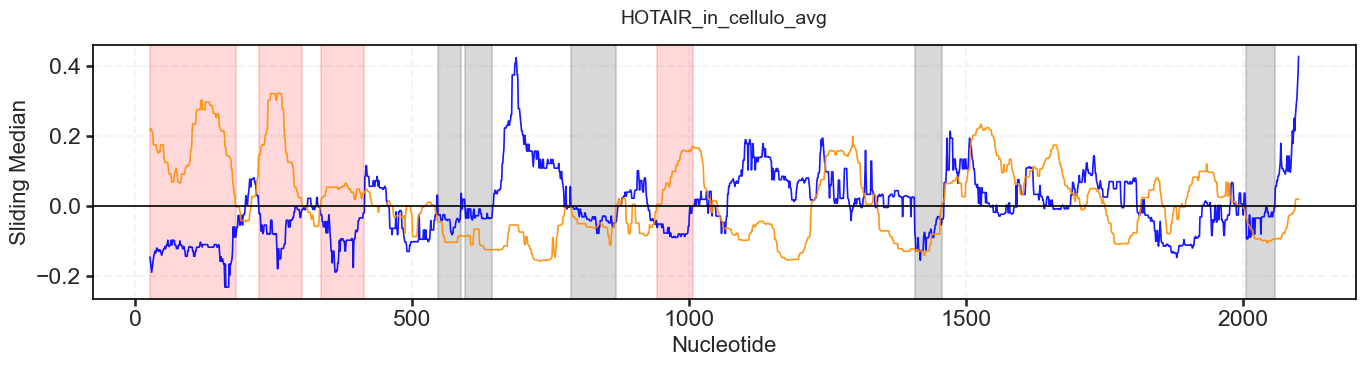


Sample HOTAIR_in_vitro_avg
2058
2058 {'Nucleotide': 0, 'Sliding_median_reactivity': 0, 'Sliding_median_shannon': 0}
Low Regions: Sample HOTAIR_in_vitro_avg: [(50, 111), (359, 513), (733, 887), (1405, 1453), (1851, 1905)]
High Regions: Sample HOTAIR_in_vitro_avg: [(112, 179), (1289, 1328), (1454, 1509), (1629, 1678), (1764, 1821), (1916, 1979)]


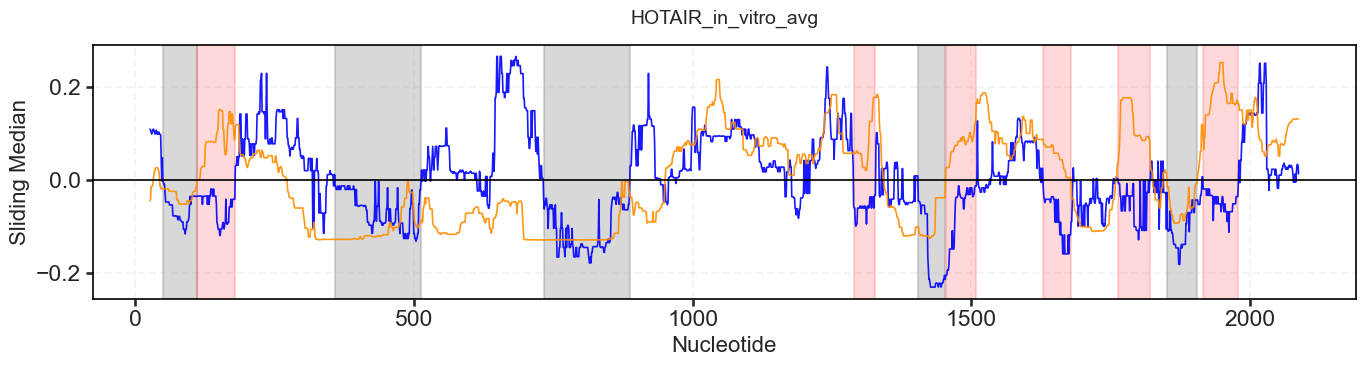

In [38]:
# RS Overlay

for sample in samples:
    df = data_dict[sample].dropna(subset=['Norm_profile'])
    x = df['Nucleotide']

    low_regions, delta_r, delta_s = get_lowSS_regions(df,'Nucleotide','Sliding_median_reactivity','Sliding_median_shannon',global_medians_reactivity[sample],global_medians_shannon[sample],40, True, False)
    high_regions, delta_r, delta_s = get_lowSS_regions(df,'Nucleotide','Sliding_median_reactivity','Sliding_median_shannon',global_medians_reactivity[sample],global_medians_shannon[sample],40, False, False)

    print(f"\nSample {sample}")
    print(len(x))
    print(len(df), df[['Nucleotide','Sliding_median_reactivity','Sliding_median_shannon']].isna().sum().to_dict())
    print(f"Low Regions: Sample {sample}: {[(int(start), int(end)) for start, end in low_regions]}")
    print(f"High Regions: Sample {sample}: {[(int(start), int(end)) for start, end in high_regions]}")
    
    line_plot(x, delta_r, plot_title=f'{sample}', color='blue',label='Reactivity',overlay=False,show=False)
    line_plot(x, delta_s, plot_y_label="Sliding Median", label='Shannon',color='darkorange',overlay=True,show=False)
    
    plt.axhline(0, color='black', linestyle='-', linewidth=1.2, alpha=1)

    for x_start, x_end in low_regions:
        plt.axvspan(x_start, x_end, color='gray', alpha=0.3)
        
    for x_start, x_end in high_regions:
        plt.axvspan(x_start, x_end, color='red', alpha=0.15)
            
    plt.tight_layout()
    # plt.savefig(f"INSERT/PATH/TO/SAVE/{sample}_RS_Overlay.png", dpi=300)
    plt.show()


Sample HOTAIR_in_cellulo_avg
2071
2071 {'Nucleotide': 0, 'Sliding_median_reactivity': 0, 'Sliding_median_shannon': 0}
Low Regions: Sample HOTAIR_in_cellulo_avg: [(27, 198), (224, 286), (335, 412), (482, 544), (547, 587), (814, 870), (930, 1001), (1408, 1460), (1824, 1926)]
High Regions: Sample HOTAIR_in_cellulo_avg: [(112, 179), (1289, 1328), (1454, 1509), (1629, 1678), (1764, 1821), (1916, 1979)]


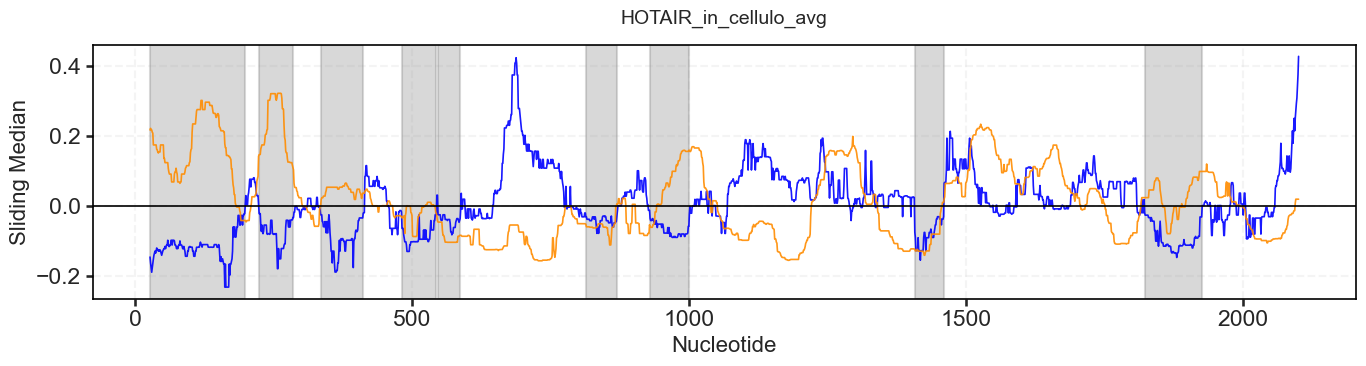


Sample HOTAIR_in_vitro_avg
2058
2058 {'Nucleotide': 0, 'Sliding_median_reactivity': 0, 'Sliding_median_shannon': 0}
Low Regions: Sample HOTAIR_in_vitro_avg: [(54, 135), (472, 512), (733, 887), (1289, 1328), (1405, 1476), (1630, 1681), (1845, 1912), (1928, 1978)]
High Regions: Sample HOTAIR_in_vitro_avg: [(112, 179), (1289, 1328), (1454, 1509), (1629, 1678), (1764, 1821), (1916, 1979)]


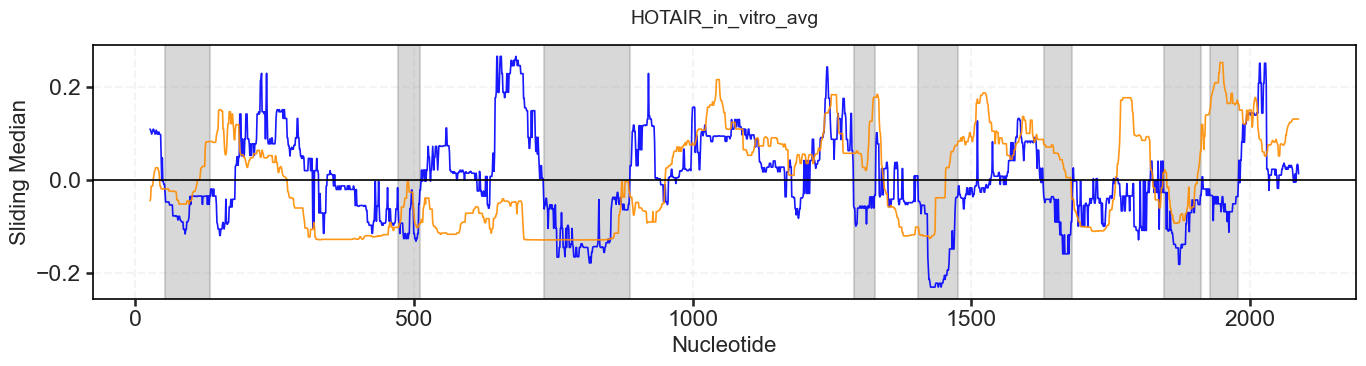

In [39]:
# Only LowSHAPE Regions

for sample in samples:
    df = data_dict[sample].dropna(subset=['Norm_profile'])
    x = df['Nucleotide']

    low_regions, delta_r, delta_s = get_lowSS_regions(df,'Nucleotide','Sliding_median_reactivity','Sliding_median_shannon',global_medians_reactivity[sample],global_medians_shannon[sample],40, False, True)

    print(f"\nSample {sample}")
    print(len(x))
    print(len(df), df[['Nucleotide','Sliding_median_reactivity','Sliding_median_shannon']].isna().sum().to_dict())
    print(f"Low Regions: Sample {sample}: {[(int(start), int(end)) for start, end in low_regions]}")
    print(f"High Regions: Sample {sample}: {[(int(start), int(end)) for start, end in high_regions]}")
    
    line_plot(x, delta_r, plot_title=f'{sample}', color='blue',label='Reactivity',overlay=False,show=False)
    line_plot(x, delta_s, plot_y_label="Sliding Median", label='Shannon',color='darkorange',overlay=True,show=False)
    
    plt.axhline(0, color='black', linestyle='-', linewidth=1.2, alpha=1)

    for x_start, x_end in low_regions:
        plt.axvspan(x_start, x_end, color='gray', alpha=0.3)
            
    plt.tight_layout()
    # plt.savefig(f"INSERT/PATH/TO/SAVE/{sample}_LowSHAPE.png", dpi=300)
    plt.show()

### Plotting Normalized Reactivities

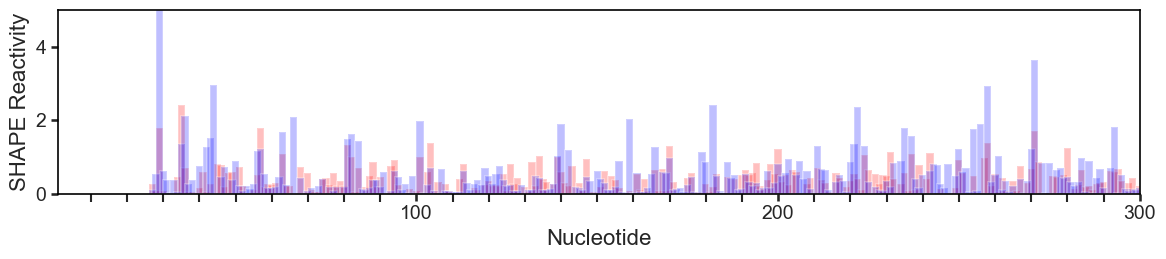

In [43]:
sample1 = 'HOTAIR_in_cellulo_avg'
sample2 = 'HOTAIR_in_vitro_avg'

df1 = data_dict[sample1].dropna(subset=['Norm_profile'])
x1 = df1['Nucleotide']
y1 = df1['Norm_profile']

df2 = data_dict[sample2].dropna(subset=['Norm_profile'])
x2 = df2['Nucleotide']
y2 = df2['Norm_profile']

fig, ax = plt.subplots(figsize=(12, 3))

ax.bar(x1, y1, width=2.0, color='red', alpha=0.25, label=sample1) #edgecolor='black', linewidth=0.1)
ax.bar(x2, y2, width=2.0, color='blue', alpha=0.25, label=sample2) #edgecolor='black', linewidth=0.1)
# ax.bar(x3, y3, width=1.0, color='purple', alpha=0.6, label=sample3)

ax.set_xlabel('Nucleotide', fontsize='16')
ax.set_ylabel('SHAPE Reactivity', fontsize='16')
ax.tick_params(axis='both', labelsize=14)
# ax.legend(loc='upper left')
ax.set_ylim(0, 5)
ax.set_xlim(1, 300) # ADJUST NUCLEOTIDES AS NEEDED FOR VISUALIZATION

ax.xaxis.set_major_locator(MultipleLocator(100))  # major ticks
ax.xaxis.set_minor_locator(MultipleLocator(10))  # minor ticks
# ax.tick_params(axis='x', which='minor', length=3, width=1.5)

plt.tight_layout()
# plt.savefig(f"INSERT/PATH/TO/SAVE/{sample}_Reactivities.png", dpi=300)
plt.show()

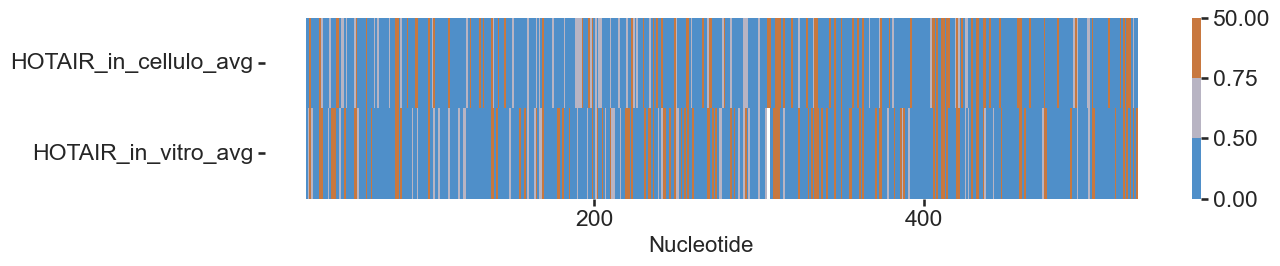

In [44]:
from matplotlib.colors import ListedColormap, BoundaryNorm

bounds = [0, 0.5, 0.75, 50]
colors = ["#4F8FC9", "#B8B4C3", "#C8783F"]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

samples = ['HOTAIR_in_cellulo_avg', 'HOTAIR_in_vitro_avg']

rows = []
for s in samples:
    y = data_dict[s]['Norm_profile'].values
    # y = np.clip(y, 0, 5)
    rows.append(y)

heat = np.vstack(rows)

fig, ax = plt.subplots(figsize=(14, 3))

sns.heatmap(
    heat,
    cmap=cmap,
    norm=norm,
    xticklabels=200,
    yticklabels=samples,
    cbar=True
)

ax.set_xlim(1,530)
ax.set_xlabel("Nucleotide")
plt.tight_layout()

### deltaSHAPE Analysis

Comparison of *in cellulo* and *in vitro* SHAPE-MaP data to identify areas of protection or accessiblity in cells.

#### Read data from Excel

In [48]:
#Path to data file
file_path = "Data_input/Supplemental_Data_3_HOTAIR_deltaSHAPE.xlsx"

# Read all sheets into a dictionary of DataFrames
data_dict = pd.read_excel(file_path, sheet_name=None)

# Check sheet names
print(data_dict.keys())

dict_keys(['cellulo_minus_vitro', 'vitro_minus_cellulo', 'vitro_minus_cellulo_all_nts'])


In [53]:
# Check one sheet
df = data_dict['vitro_minus_cellulo_all_nts']
df.head(10)

,Nuc,Seq,DeltaSHAPE,Z-factor,Std_Score,Smoothed_Data1,Smoothed_Data2,Unsmoothed_Diff,Data1,Data2,Smoothed_Data1 - Smoothed_Data2
0,1,G,0.0,-999,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,NaN
1,2,A,0.0,-999,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,NaN
2,3,C,0.0,-999,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,NaN
3,4,U,0.0,-999,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,NaN
4,5,C,0.0,-999,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,NaN
5,6,G,0.0,-999,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,NaN
6,7,C,0.0,-999,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,NaN
7,8,C,0.0,-999,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,NaN
8,9,U,0.0,-999,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,NaN
9,10,G,0.0,-999,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,NaN


#### Plot deltaSHAPE values

In [55]:
sample = 'vitro_minus_cellulo_all_nts'
s1=data_dict[sample]['Smoothed_Data1']
s2=data_dict[sample]['Smoothed_Data2']
# Convert "-999" values to NaN prior to subtraction
s1 = s1.replace(-999, np.nan)
s2 = s2.replace(-999, np.nan)
delta = s1 - s2
x = data_dict[sample]['Nuc']
print(len(x))

2148


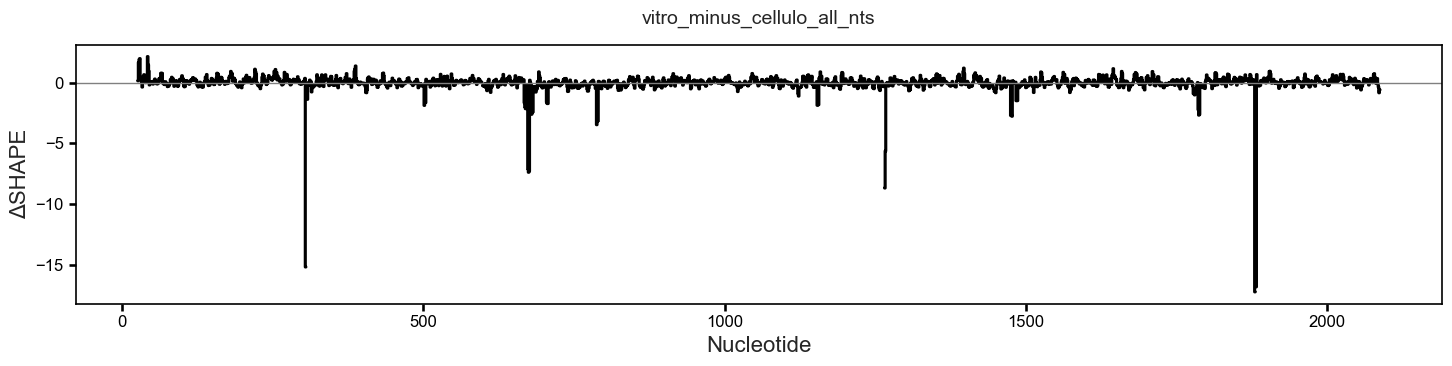

In [56]:
# Prepare figure
fig, ax = plt.subplots(figsize=(15, 4))

# Plot
ax.plot(x, delta, drawstyle='steps-mid', color='black')
ax.axhline(0, color='gray', linewidth=1)

# Figure labeling
ax.set_title(f"{sample}", pad=15)
ax.set_xlabel('Nucleotide', fontsize='16')
ax.set_ylabel('ΔSHAPE', fontsize='16')
ax.tick_params(axis='both', labelsize=12, colors='black')
plt.tight_layout()
plt.show()

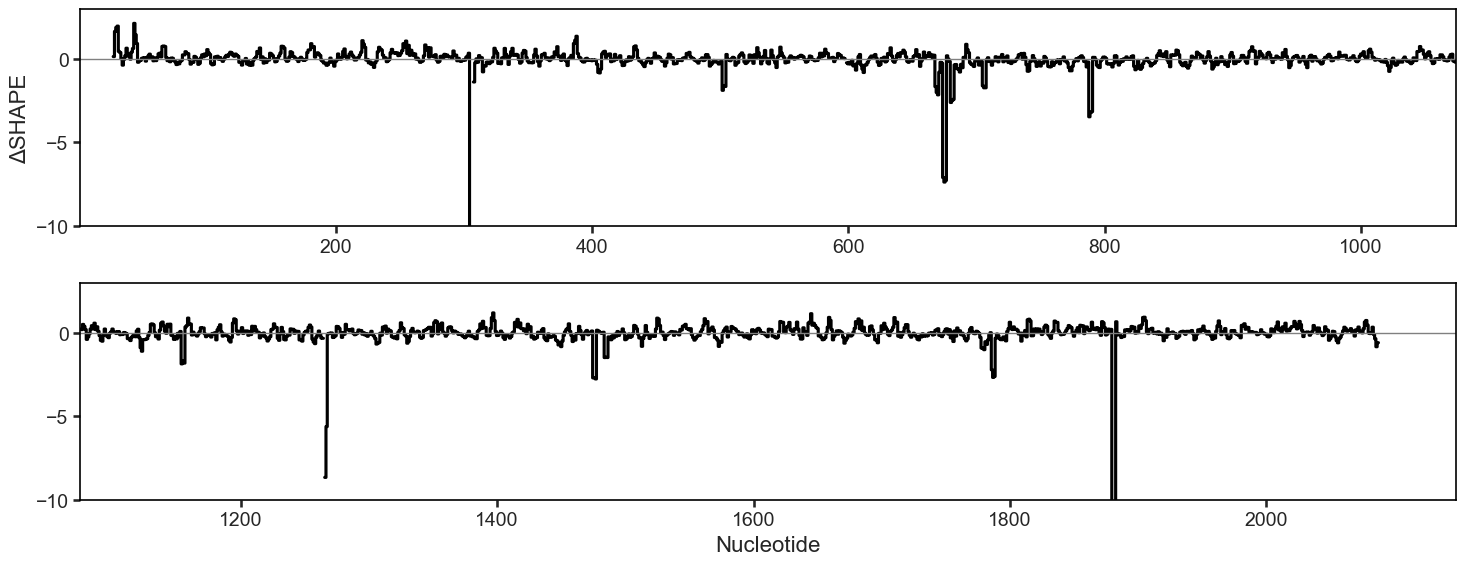

In [57]:
# Split data in half for better visualization
mid = len(delta) // 2

# Prepare figure
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharey=True)

# first half
axes[0].plot(x[:mid], delta[:mid], drawstyle='steps-mid', color='black')
axes[0].axhline(0, color='gray', linewidth=1)
axes[0].set_xlim(1, mid)
axes[0].set_ylim(-10, 3)
axes[0].set_ylabel('ΔSHAPE', fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)

# second half
axes[1].plot(x[mid:], delta[mid:], drawstyle='steps-mid', color='black')
axes[1].axhline(0, color='gray', linewidth=1)
axes[1].set_xlim(mid+1, len(delta))
axes[0].set_ylim(-10, 3)
axes[1].set_xlabel('Nucleotide', fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

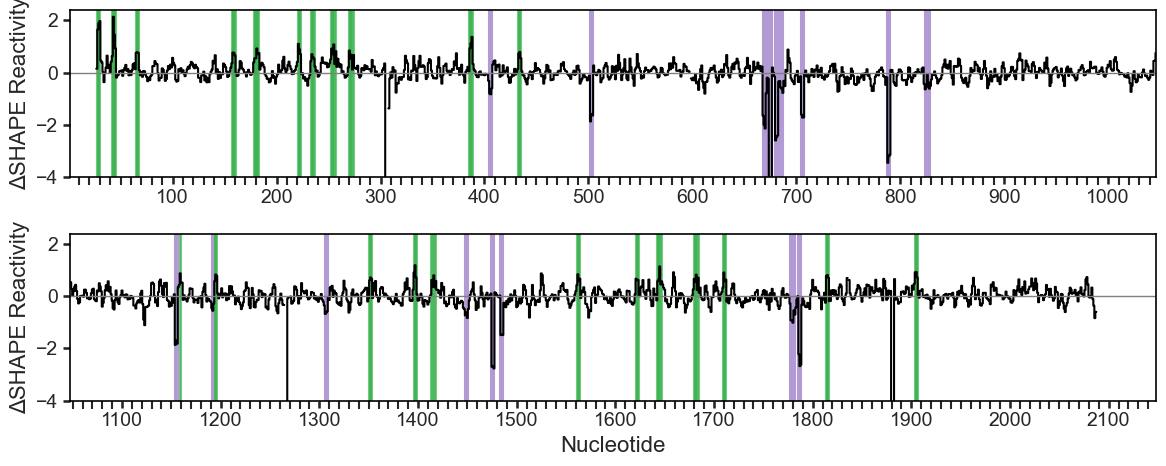

In [60]:
# Plot with different domains

# Domain boundaries
splits = [(1, 1046), (1047, 2148)]

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharey=True)

for ax, (start, end) in zip(axes, splits):
    # convert to 0-indexed slice positions
    start_idx, end_idx = start - 1, end  # to include end nt
    ax.plot(x[start_idx:end_idx], delta[start_idx:end_idx],
            drawstyle='steps-mid', color='black', linewidth=1.5)

    # Highlight nucleotides with a significant deltaSHAPE value
    sig = data_dict[sample]['DeltaSHAPE'].iloc[start_idx:end_idx]
    
    ### Highlighting method #1: Entire y axis pan
    # positive significant nucleotides → full-height green shading
    for pos in np.where(sig > 0)[0]:
        ax.axvspan(x[start_idx + pos] - 0.5,
                   x[start_idx + pos] + 0.5,
                   color='#3EB452', alpha=0.7)
    # negative significant nucleotides → full-height purple shading
    for neg in np.where(sig < 0)[0]:
        ax.axvspan(x[start_idx + neg] - 0.5,
                   x[start_idx + neg] + 0.5,
                   color='#B29BD4', alpha=1)

    ### Highlighting method #2: Within the curve
    # # highlight positive significant nucleotides
    # ax.fill_between(
    #     x[start_idx:end_idx],
    #     0,
    #     delta[start_idx:end_idx],
    #     where=(sig > 0),
    #     step='mid',
    #     alpha=0.7,
    #     color='#3EB452'
    # )
    # # highlight negative significant nucleotides
    # ax.fill_between(
    #     x[start_idx:end_idx],
    #     0,
    #     delta[start_idx:end_idx],
    #     where=(sig < 0),
    #     step='mid',
    #     alpha=1,
    #     color='#B29BD4'
    # )

    # Other plot parameters
    ax.axhline(0, color='gray', linewidth=1)
    ax.set_xlim(start, end)
    ax.set_ylim(-4, 2.4)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_ylabel("ΔSHAPE Reactivity", fontsize=16)
    ax.xaxis.set_major_locator(MultipleLocator(100))  # major ticks
    ax.xaxis.set_minor_locator(MultipleLocator(10))  # minor ticks

# axis labeling
axes[-1].set_xlabel("Nucleotide", fontsize=16)

plt.tight_layout()
# plt.savefig(f"INSERT/PATH/TO/SAVE/HOTAIR_deltaSHAPE.png", dpi=300)
plt.show()


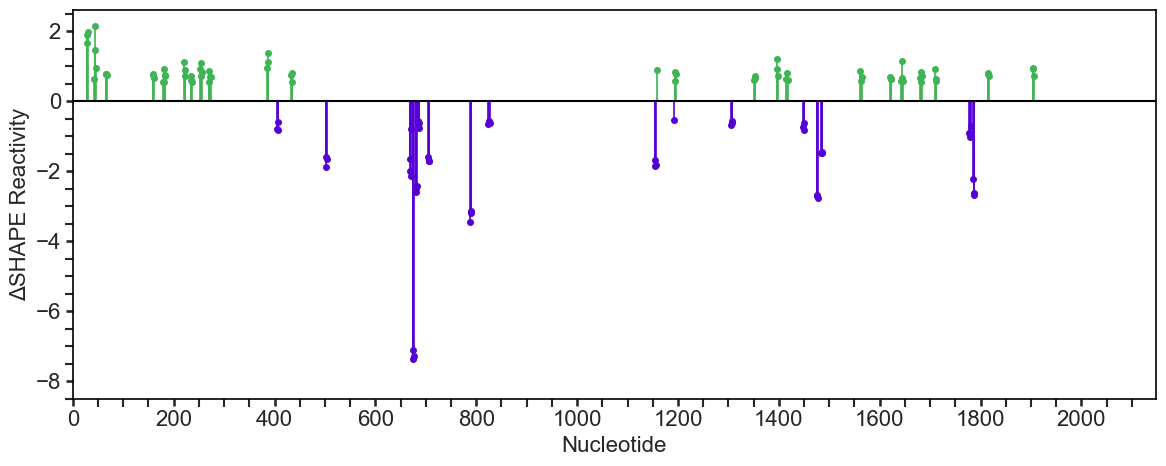

In [72]:
# Lollipop plot
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

for i, (pos, val) in enumerate(zip(x, delta)):
    if data_dict[sample]['DeltaSHAPE'].iloc[i] > 0:
        ax.vlines(pos, 0, val, color='#3EB452', linewidth=1.2)
        ax.plot(pos, val, 'o', color='#3EB452', markersize=4)
    elif data_dict[sample]['DeltaSHAPE'].iloc[i] < 0:
        ax.vlines(pos, 0, val, color='#5500D5', linewidth=1.2)
        ax.plot(pos, val, 'o', color='#5500D5', markersize=4)

ax.axhline(0, color='black', linewidth=1.5)
ax.set_xlim(0, 2148)
ax.set_ylim(-8.5, 2.6)
ax.tick_params(axis='both', labelsize=16)
ax.set_ylabel("ΔSHAPE Reactivity", fontsize=16)
ax.set_xlabel("Nucleotide", fontsize=16)
ax.xaxis.set_major_locator(MultipleLocator(200))
ax.xaxis.set_minor_locator(MultipleLocator(50))
ax.yaxis.set_major_locator(MultipleLocator(2))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))

plt.tight_layout()
# plt.savefig(f"INSERT/PATH/TO/SAVE/HOTAIR_deltaSHAPE_peaks.png", dpi=300)
# plt.savefig(f"test.png", dpi=300)
plt.show()


### Jaccard Calculation

#### Parse CT file

In [2]:
# Read in CT file and extract sequence and structure information
def parse_ct(filename):
    struct = {} # dictionary of base pairs
    seq = [] # list of nucleotides
    with open(filename) as f:
        for line in f:
            cols = line.strip().split() # remove extra spaces at beginning/end and split by any whitespace
            if len(cols) < 6: # skip header
                continue
            i = int(cols[0])
            nt = cols[1]
            pair = int(cols[4])
            seq.append(nt)
            struct[i] = pair
    return seq, struct

#### Convert to base pair set

In [3]:
# Generate set of all unique base pairs for a structure
def bp_set(struct):
    bps = set()
    for i, j in struct.items():
        if j > 0: # only add base pairs
            bps.add((min(i, j), max(i, j)))
    return bps

#### Filter base pairs for window analysis

In [4]:
# Only return base pairs that fall within a specified window
def bps_in_window(bps, start, end):
    return { (i, j) for (i, j) in bps if start <= i <= end and start <= j <= end }

#### Compute Jaccard similarity

Structural similarity score: size of intersection / size of union of base pair sets

In [5]:
def jaccard(a, b):
    if len(a | b) == 0: # union
        return 0.0
    return len(a & b) / len(a | b) # intersection / union

#### Sliding window similarity analysis

In [6]:
# Calculate similarity score in sliding windows for two RNA structures
def sliding_window_jaccard(bps1, bps2, length=2148, window=301, step=1):
    """
    bps1, bps2: base pair sets to compare
    length: total RNA length in nts (from CT file), default = 2148 for HOTAIR
    window: window size in nts, default = 301 (odd for symmetry around center nt)
    step: step size in nts, default = 1
    returns: DataFrame with similarity score per center nt
    """
    results = []

    for pos in range(1, length + 1, step):
        # define window around current position
        start = max(1, pos - window // 2)
        end   = min(length, pos + window // 2)

        # base pairs in this window
        local1 = bps_in_window(bps1, start, end)
        local2 = bps_in_window(bps2, start, end)

        score = jaccard(local1, local2)

        results.append({
            "Center Nucleotide": pos,
            "Jaccard": score
        })

    return pd.DataFrame(results)

#### Apply Jaccard Analysis & Plot

In [7]:
# Parse CT files:
seq1, struct1 = parse_ct("Superfold_structures/HOTAIR_cellulo_2A3_AVERAGE.ct")
seq2, struct2 = parse_ct("Superfold_structures/HOTAIR_vitro_2A3_AVERAGE.ct")
seq3, struct3 = parse_ct("Superfold_structures/HOTAIR_silico.ct")

bps1 = bp_set(struct1)
bps2 = bp_set(struct2)
bps3 = bp_set(struct3)

df12 = sliding_window_jaccard(bps1, bps2)
df13 = sliding_window_jaccard(bps1, bps3)
df23 = sliding_window_jaccard(bps2, bps3)

In [8]:
# check dataframe
display(df12)

,Center Nucleotide,Jaccard
0,1,0.800000
1,2,0.800000
2,3,0.800000
3,4,0.800000
4,5,0.800000
...,...,...
2143,2144,0.170213
2144,2145,0.170213
2145,2146,0.170213
2146,2147,0.170213


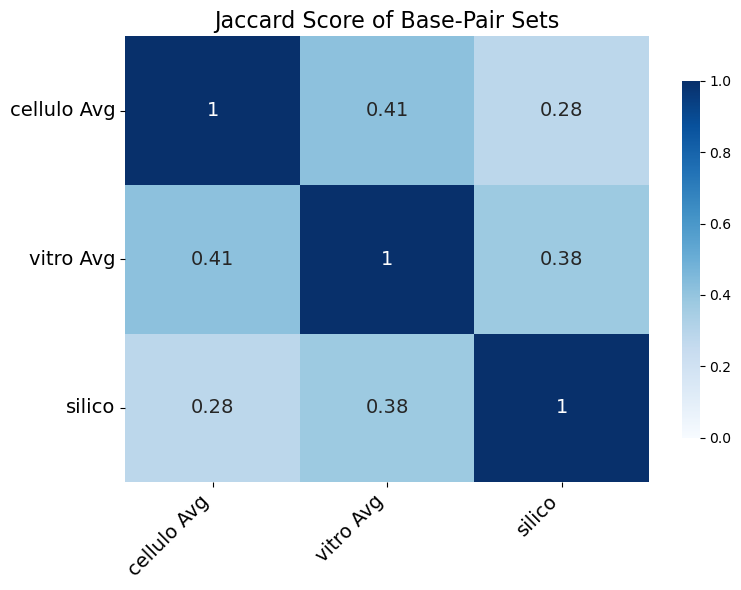

In [9]:
# Global Jaccard Score

bps_dict = {
    "cellulo Avg": bps1,
    "vitro Avg": bps2,
    "silico": bps3
}

names = list(bps_dict.keys())
matrix = []

# pairwise calculations
for i in names:
    row = []
    for j in names:
        row.append(jaccard(bps_dict[i], bps_dict[j]))
    matrix.append(row)

jaccard_df = pd.DataFrame(matrix, index=names, columns=names)

plt.figure(figsize=(8,6))
sns.heatmap(jaccard_df, annot=True, cmap="Blues", vmin=0, vmax=1, annot_kws={"size": 14}, cbar_kws={"shrink": 0.8})
plt.xticks(fontsize=14, rotation=45, ha="right")
plt.yticks(fontsize=14, rotation=0)
plt.title("Jaccard Score of Base-Pair Sets", fontsize=16)
plt.tight_layout()
# plt.savefig(f"INSERT/PATH/TO/SAVE/Jaccard_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

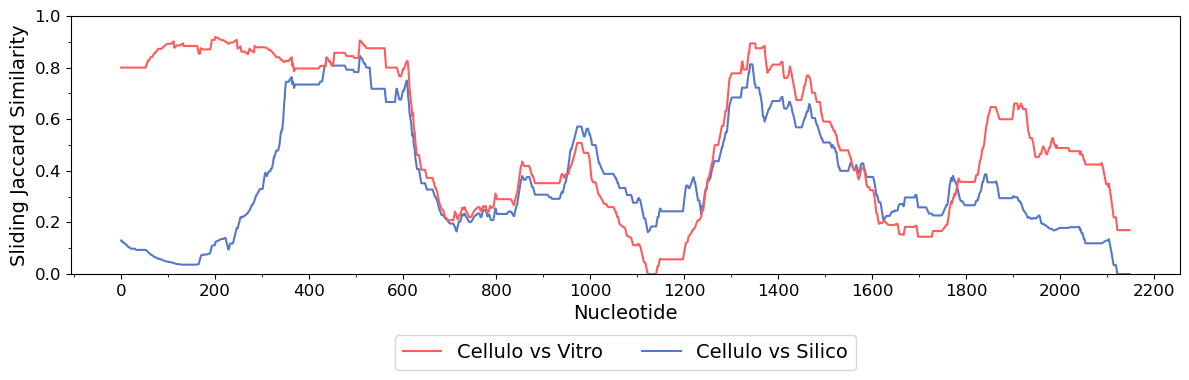

In [12]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(df12["Center Nucleotide"], df12["Jaccard"], label="Cellulo vs Vitro", color="#FF5C5C", linewidth=1.5, linestyle="-", zorder=2)
ax.plot(df13["Center Nucleotide"], df13["Jaccard"], label="Cellulo vs Silico", color="#5578C8", linewidth=1.5, linestyle="-", zorder=1)
# ax.plot(df23["Center Nucleotide"], df23["Jaccard"], label="Vitro vs Silico", color="#8a87d4", linewidth=1.5, linestyle="-")

ax.set_xlabel("Nucleotide", fontsize=14)
ax.set_ylabel("Sliding Jaccard Similarity", fontsize=14)
# fig.suptitle("Base Pair Identity Between Contexts", fontsize=14)
ax.set_ylim([0, 1.0])
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.xaxis.set_major_locator(MultipleLocator(200))
ax.tick_params(axis='both', which='both', labelsize=12)

ax.legend(loc="upper center", ncols=3, bbox_to_anchor=(0.5, -0.2), fontsize = 14)
plt.tight_layout()
# plt.savefig(f"INSERT/PATH/TO/SAVE/Jaccard_cellulo_vs_vitro_and_cellulo_vs_silico_w301.png", dpi=300, bbox_inches="tight")
plt.show()